## Detect Anomalous Vibrations in Helicopters using Graph Neural Networks

The use case is relative to flight test helicopters vibration measurements. The dataset has been collected and released by Airbus SAS. A main challenge in flight tests of heavily instrumented aircraft (helicopters or airplanes alike) is the validation of the generated data because of the number of signals to validate. Manual validation requires too much time and manpower. Automation of this validation is crucial.

In this case, different accelerometers are placed at different positions of the helicopter, in different directions (longitudinal, vertical, lateral) to measure the vibration levels in all operating conditions of the helicopter. The data set consists of multiple 1D time series with a constant frequency of 1024 Hz taken from different flights, cut into 1 minute sequences.

We are interested in the detection of abnormal sensor behaviour. Sensors are recorded at 1024Hz and we provide sequences of one-minute length.

Each CSV has 61440 columns corresponding all time steps contained in one minute at 1024Hz and are named from 0 to 61339.

Load datasets from archive

In [88]:
## archive has dfvalid_groundtruth, train_df, validation_df

import os 
import pandas as pd


archive = 'archive'

train_df = pd.read_csv(os.path.join(archive, 'train_df.csv'))
train_df = train_df.drop(columns=['Unnamed: 0'])

validation_df = pd.read_csv(os.path.join(archive, 'validation_df.csv'))
validation_df = validation_df.drop(columns=['Unnamed: 0'])
dfvalid_groundtruth = pd.read_csv(os.path.join(archive, 'dfvalid_groundtruth.csv'))

In [89]:
validation_df.head()

,0,1,2,3,4,5,6,7,8,9,...,61430,61431,61432,61433,61434,61435,61436,61437,61438,61439
0,0.070650,0.085524,0.076847,0.085524,0.120229,0.140061,0.107834,0.048340,0.014874,0.030987,...,0.018592,-0.017353,-0.049579,-0.061974,-0.022311,0.052058,0.091721,0.075608,0.045861,0.027268
1,-0.300685,-0.882656,-1.733789,-2.181179,-1.942328,-1.719240,-1.981126,-2.323034,-2.325459,-2.349708,...,0.454665,-0.782024,-1.725302,-1.829572,-1.170004,-0.278861,-0.152767,-1.035424,-2.312123,-3.199628
2,-0.056398,-0.152028,-0.058850,0.140994,0.170419,0.154480,0.270954,0.359228,0.334708,0.349420,...,0.023295,-0.019617,-0.062528,-0.094405,-0.105439,-0.123830,-0.166741,-0.159385,-0.106665,-0.131186
3,0.030618,0.020412,0.058747,0.124712,0.155828,0.161553,0.167777,0.170515,0.165038,0.141141,...,-0.073682,-0.052524,-0.023897,-0.009210,0.016429,0.058000,0.097828,0.114755,0.090360,0.054764
4,-1.071597,-6.912540,-13.677612,-16.463519,-15.790084,-11.653620,-7.668311,-9.942997,-14.321553,-13.704648,...,-5.227723,-6.107613,-6.577051,-6.123589,-5.324806,-4.965969,-4.464579,-3.442138,-3.794831,-6.133420


In [90]:
len(dfvalid_groundtruth)

594

In [91]:
# compute ground truth 
anomalies = sum(dfvalid_groundtruth['anomaly'])

print(f"Number of anomalies in ground truth: {anomalies}")

id_to_label = dict(zip(dfvalid_groundtruth["seqID"], dfvalid_groundtruth["anomaly"]))

valid_labels = []
for col in validation_df.columns:
    seq_id = int(col)
    label = id_to_label.get(seq_id, 0.0)
    valid_labels.append(int(label))


assert len(valid_labels) == len(validation_df.columns) 

Number of anomalies in ground truth: 297.0


In [92]:
import torch
import torch_geometric

class HelicopterDataset(torch_geometric.data.Dataset):
  def __init__(self, df, labels, edge_mode='chain'):
    super().__init__()

    self.df = df
    self.values = self.df.values # [T, N]
    self.num_timesteps, self.num_graphs = self.values.shape

    self.labels = torch.tensor(labels, dtype=torch.long)
    assert len(self.labels) == self.num_graphs

    if edge_mode == 'chain':
      self.edge_index = self._make_chain_edges(self.num_timesteps)
    elif edge_mode == 'full':
      self.edge_index = self._make_fully_connected_edges(self.num_timesteps)
    else:
      raise ValueError(f"Invalid edge mode: {edge_mode}")
    
  @staticmethod
  def _make_chain_edges(num_nodes):
    src = torch.arange(0, num_nodes - 1, dtype=torch.long) # directed chain edges
    dst = src + 1

    edge_index = torch.stack([torch.cat([src, dst]), torch.cat([dst, src])], dim=0) 
    return edge_index
  
  @staticmethod
  def _make_fully_connected_edges(num_nodes):
    src = torch.arange(num_nodes, dtype=torch.long).repeat_interleave(num_nodes)
    dst = torch.arange(num_nodes, dtype=torch.long).repeat(num_nodes)

    edge_index = torch.stack([torch.cat([src, dst])], dim=0)
    return edge_index
  
  def len(self):
    return self.num_graphs

  def get(self, idx):
    col = self.values[:, idx]
    x = torch.tensor(col, dtype=torch.float).unsqueeze(-1) # [T, 1]

    y = self.labels[idx].unsqueeze(0) # [1]

    data = torch_geometric.data.Data(x=x, edge_index=self.edge_index, y=y)
    return data
    

In [93]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TemporalCNNAutoencoder(nn.Module):
    def __init__(self, in_channels=1, latent_dim=32):
        super().__init__()

        # Encoder: Conv1d stack that keeps length the same (stride=1, padding to preserve)
        self.enc = nn.Sequential(
            nn.Conv1d(in_channels, 16, kernel_size=7, padding=3),  # L -> L
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=7, padding=3),           # L -> L
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=7, padding=3),           # L -> L
            nn.ReLU(),
        )

        # Bottleneck over channels (not over time, so we don't need exact L here)
        self.conv_to_latent = nn.Conv1d(64, latent_dim, kernel_size=1)
        self.conv_from_latent = nn.Conv1d(latent_dim, 64, kernel_size=1)

        # Decoder: symmetric Conv1d stack
        self.dec = nn.Sequential(
            nn.Conv1d(64, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Conv1d(32, 16, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Conv1d(16, in_channels, kernel_size=7, padding=3),
            # no activation
        )

    def forward(self, x, edge_index=None, batch=None):
        # x: [num_nodes, 1]; batch: [num_nodes] with graph indices

        # 1. get batch size and seq_len
        num_graphs = batch.max().item() + 1
        num_nodes = x.size(0)
        seq_len = num_nodes // num_graphs
        assert num_nodes % num_graphs == 0, "Graphs must have equal length"

        # 2. reshape to [batch, channels, length]
        x_seq = x.view(num_graphs, seq_len, -1).permute(0, 2, 1)  # [B, 1, L]

        # 3. encode
        h = self.enc(x_seq)                  # [B, 64, L]
        z = self.conv_to_latent(h)           # [B, latent_dim, L]

        # 4. decode
        h_dec = self.conv_from_latent(z)     # [B, 64, L]
        x_hat_seq = self.dec(h_dec)          # [B, 1, L] (same length)

        # 5. reshape back to [num_nodes, 1]
        x_hat = x_hat_seq.permute(0, 2, 1).reshape(num_nodes, -1)

        return x_hat, z


In [94]:
from torch_geometric.loader import DataLoader

num_train_graphs = train_df.shape[1]
train_labels = [0] * num_train_graphs
train_dataset = HelicopterDataset(train_df, labels=train_labels, edge_mode='chain')
valid_dataset = HelicopterDataset(validation_df, labels=valid_labels, edge_mode='chain')


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

In [96]:
from tqdm.auto import tqdm

device = torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')
print(f'Using device: {device}')

model = TemporalCNNAutoencoder(in_channels=1, latent_dim=16).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
recon_loss = nn.MSELoss()

n_epochs = 10
for epoch in range(n_epochs):
    model.train()
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs}")
    for batch in loop:
        batch = batch.to(device)
        optimizer.zero_grad()
        x_hat, latent = model(batch.x, batch.edge_index, batch.batch)
        loss = recon_loss(x_hat, batch.x)
        loss.backward()
        optimizer.step()
        loop.set_postfix(loss=f"{loss.item():.4f}")


Using device: mps


Epoch 10/10: 100%|██████████| 1920/1920 [00:41<00:00, 46.11it/s, loss=0.0000]


In [97]:
model.eval()
anomaly_scores = []
all_labels = []

with torch.no_grad():
    for batch in valid_loader:
        batch = batch.to(device)
        x_hat, latent = model(batch.x, batch.edge_index, batch.batch)
        node_err = (x_hat - batch.x).pow(2).mean(dim=-1)
        
        # Aggregate to graph-level
        graph_err = torch.zeros(batch.num_graphs, device=x_hat.device)
        graph_err.scatter_add_(0, batch.batch, node_err)
        counts = torch.bincount(batch.batch)
        graph_err = graph_err / counts
        
        anomaly_scores.extend(graph_err.cpu().tolist())
        all_labels.extend(batch.y.cpu().tolist())


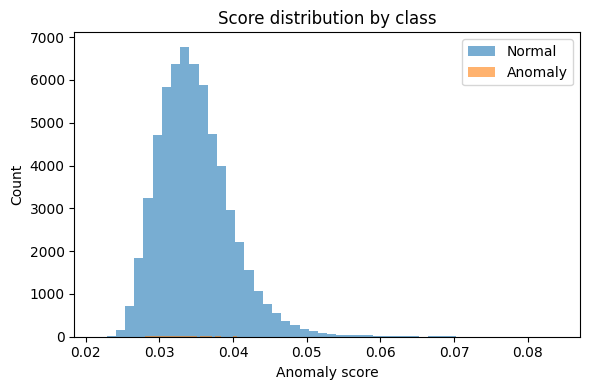

In [98]:
import numpy as np
import matplotlib.pyplot as plt

scores = np.array(anomaly_scores)
labels = np.array(valid_labels)  # 0 = normal, 1 = anomaly

plt.figure(figsize=(6,4))
plt.hist(scores[labels == 0], bins=50, alpha=0.6, label="Normal")
plt.hist(scores[labels == 1], bins=50, alpha=0.6, label="Anomaly")
plt.xlabel("Anomaly score")
plt.ylabel("Count")
plt.legend()
plt.title("Score distribution by class")
plt.tight_layout()
plt.show()
